# ReefSafe: Evidence-Bounded Reef Screening
**DOSM Datathon 2026 - Machine Learning and Artificial Intelligence for Sustainable Tourism**

ReefSafe answers four decision-focused objectives:

1. **Identify Associated Factors:** Examine lagged associations between reef change, regional thermal stress, water-quality indicators, and documented local disturbances.
2. **Compare Available Stressor Evidence:** Compare observed thermal and local-pressure signals without claiming causal percentages. Available data cannot quantify the percentage caused by tourism.
3. **Prioritise Field Verification:** Rank monitoring units for ranger verification using observed condition, a next-observation screening estimate, uncertainty, and recorded stressors.
4. **Frame Conservation with Economic Context:** Use the published RM8.7 billion annual benchmark for six evaluated Malaysian marine-park archipelagos during 2011-2015. This is context, not a ReefSafe economic calculation.

> **Decision boundary:** ReefSafe is a screening queue. It does not calculate legal visitor capacity, prove causality, estimate island revenue, or guarantee an intervention outcome.


---
## Phase 1: Data Provenance

| Evidence | Publisher | Scope | Use |
|---|---|---|---|
| Reef surveys | Reef Check Malaysia | 404 monitoring-unit/year observations | Ecological condition and documented impact mentions |
| Thermal context | NOAA Coral Reef Watch | Five regional virtual stations | Supporting regional heat signal, subject to DOSM eligibility confirmation |
| Marine-park visitors | Jabatan Taman Laut / data.gov.my | Verified portal scope: 2000-2009 | National context only; never allocated to monitoring units |
| Total Economic Value | Department of Marine Park Malaysia | Six evaluated archipelagos, 2011-2015 | Historical literature benchmark only |

The primary economic source is `TOTAL ECONOMIC VALUE OF MARINE BIODIVERSITY.pdf`. Its component values are transcribed with source pages in `dmpm_tev_2011_2015.csv`.


In [1]:
import csv
import json
import runpy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.economic_valuation import load_dmpm_tev
from scripts.train_models import FEATURES, main as train_models

get_ipython().run_line_magic("matplotlib", "inline")

print(f"Repository root: {ROOT}")


Repository root: C:\Users\Chee\Documents\dosm2026\.worktrees\reefsafe-recovery


---
## Phase 2: Preprocessing

Run the repository's production preprocessing and modeling scripts. The notebook does not maintain a second feature list, model-selection rule, or ranking implementation.


In [2]:
runpy.run_path(str(ROOT / "scripts/run_preprocessing.py"), run_name="__main__")
train_models()

processed = ROOT / "data/processed"
master = pl.read_csv(processed / "master_reef_tourism_dataset.csv")
annual = pl.read_csv(processed / "survey_year_summary.csv")
paired = pl.read_csv(processed / "paired_change_summary.csv")
factors = pl.read_csv(processed / "factor_relationships.csv")
all_factors = pl.read_csv(processed / "all_factor_relationships.csv")
priority = pl.read_csv(processed / "reef_priority_predictions.csv")
validation_by_year = pl.read_csv(processed / "model_validation_by_year.csv")
metrics = json.loads((ROOT / "output/model_evaluation_metrics.json").read_text())
tev = load_dmpm_tev()

print(f"Rows: {master.height}; monitoring units: {master['island'].n_unique()}")
print(f"Selected model: {metrics['best_candidate']}")


STEP 1: INSPECT RAW STRUCTURED DATA BEFORE COMBINING



[1] Reef Check Survey Panel (model_ready): 404 rows, 40 columns
Columns: ['survey_year', 'island', 'state', 'ecoregion', 'n_sites', 'live_coral_cover_pct', 'lcc_prev', 'years_since_prev', 'lcc_change', 'lcc_change_rate'] ... (total 40 )
Null counts per column BEFORE merge:
  - survey_year                 :   0 nulls (Clean)
  - island                      :   0 nulls (Clean)
  - state                       :   0 nulls (Clean)
  - ecoregion                   :   2 nulls (0.5%)
  - n_sites                     :  66 nulls (16.3%)
  - live_coral_cover_pct        :   0 nulls (Clean)
  - lcc_prev                    :  56 nulls (13.9%)
  - years_since_prev            :  56 nulls (13.9%)
  - lcc_change                  :  56 nulls (13.9%)
  - lcc_change_rate             :  56 nulls (13.9%)
  - region_avg_lcc_pct          :   4 nulls (1.0%)
  - island_vs_region_pct        :   4 nulls (1.0%)
  - grp_other                   :  10 nulls (2.5%)
  - grp_available_substrate     :  10 nulls (2.5%)
  

  -> Extracted 210 station-year annual thermal stress profiles.

[4] OpenDOSM Datasets:
  - GDP State Real Supply: 2163 records
  - Marine Fish Landings: 1368 records across states 16
  - River Basin Water Quality: 198 records

STEP 2: STEP-BY-STEP DATA COMBINATION & HARMONIZATION
Join 1 (RC + JUPEM Geocoding): 404 rows, 43 columns
  - Missing Coordinates count: 0 (CLEAN 100%)
Join 2 (+ NOAA Thermal Stress): 404 rows, 46 columns
Join 3 (+ Accommodation Capacity): 404 rows, 50 columns
OpenDOSM context files retained for descriptive use; no island-level tourism values were inferred.

STEP 3: POST-COMBINATION AUDIT & DATA VERIFICATION
Final Merged Dataset Dimensions: 404 rows x 50 columns

Post-Combination Null Audit:
  - survey_year                   : OK (0 nulls)
  - island                        : OK (0 nulls)
  - state                         : OK (0 nulls)
  - ecoregion                     : 2 nulls (0.5%)
  - n_sites                       : 66 nulls (16.3%)
  - live_coral_cover_pct

Past-only transitions: 348
Forward evaluation observations: 183
Baseline mean        MAE=5.99 RMSE=8.10 R2=-0.019
Ridge regression     MAE=5.99 RMSE=7.94 R2=+0.021
Gradient boosting    MAE=5.86 RMSE=7.74 R2=+0.070
Random forest        MAE=6.07 RMSE=8.02 R2=+0.002
Selected candidate: Gradient boosting; MAE improvement over baseline: +2.2%
Rows: 404; monitoring units: 56
Selected model: Gradient boosting


### Graph 1: Availability of verified model inputs

This chart reports availability before median imputation. It excludes accommodation fields because their row-level provenance is not yet sufficient for scored use.


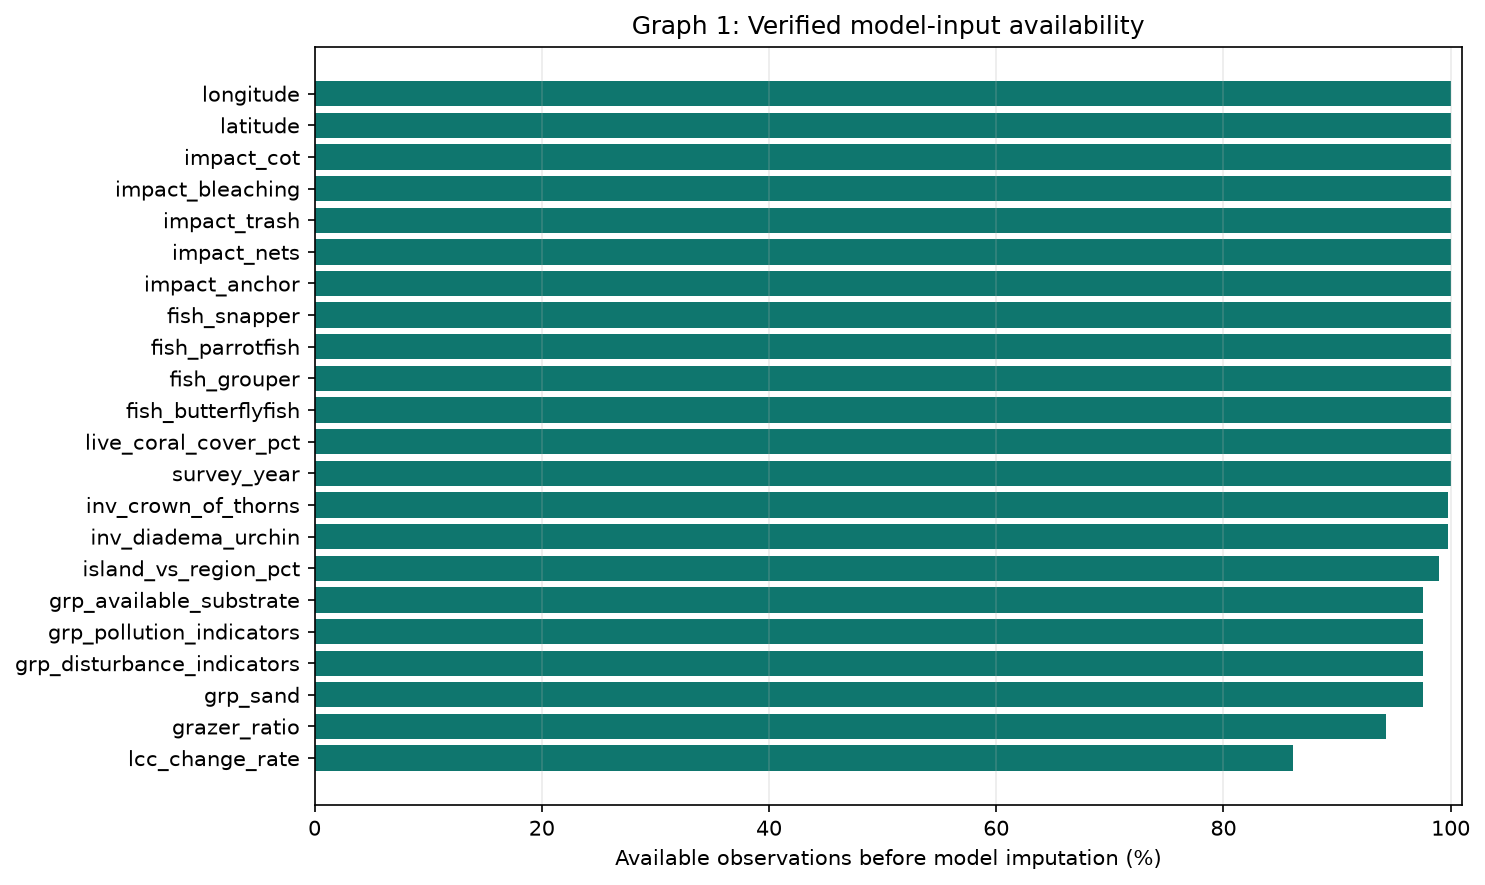

In [3]:
availability = [100 * (1 - master[name].null_count() / master.height) for name in FEATURES]
order = np.argsort(availability)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.barh([FEATURES[i] for i in order], [availability[i] for i in order], color="#0f766e")
ax.set_xlim(0, 101)
ax.set_xlabel("Available observations before model imputation (%)")
ax.set_title("Graph 1: Verified model-input availability")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


---
## Phase 3: Exploratory Data Analysis

### Graph 2: Tourism Data Gap

The official portal cited in this repository explicitly covers 2000-2009. Later values remain excluded until their original records are preserved and traced.


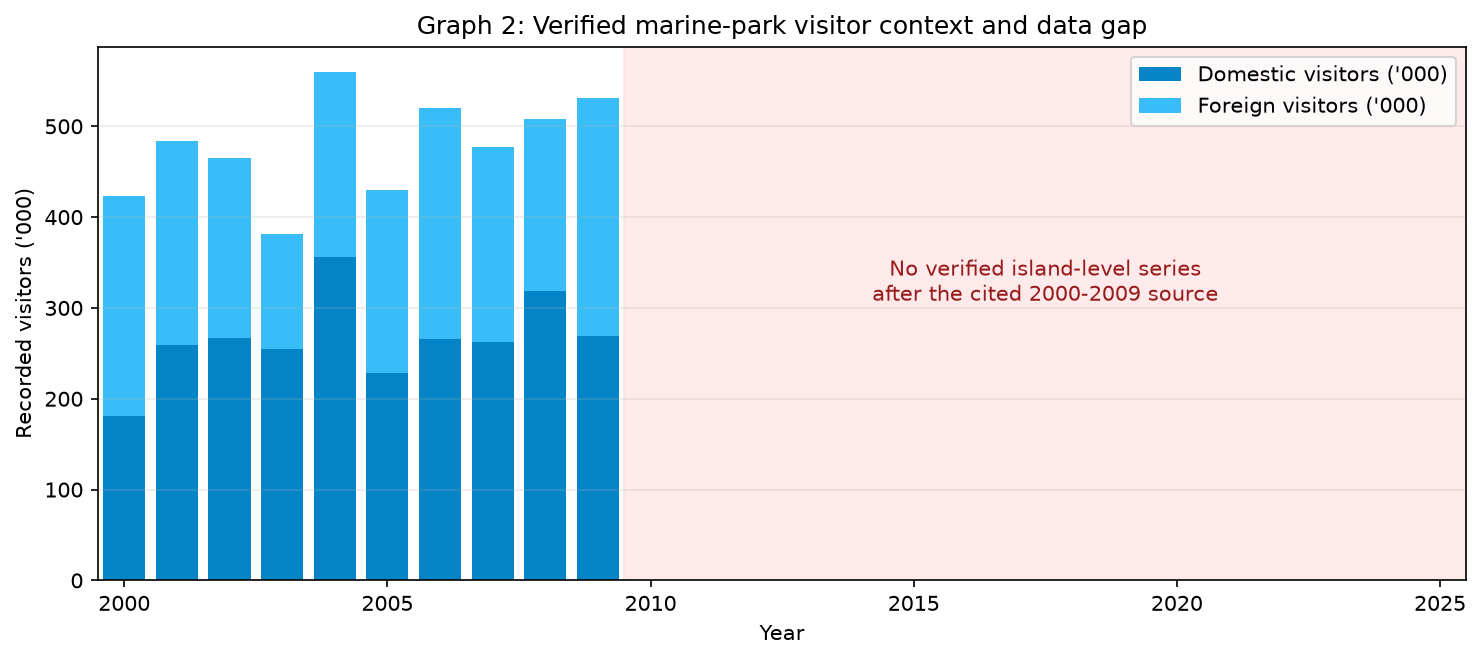

In [4]:
visitor_path = ROOT / "data/raw/structured/taman_laut_visitors_2000_2017.csv"
with visitor_path.open(encoding="utf-8") as stream:
    visitor_rows = [row for row in csv.DictReader(stream) if int(row["year"]) <= 2009]

visitor = pl.DataFrame(visitor_rows).with_columns([
    pl.col("year").cast(pl.Int64),
    pl.col("domestic_visitors").cast(pl.Int64),
    pl.col("foreign_visitors").cast(pl.Int64),
])
visitor_annual = visitor.group_by("year").agg([
    pl.col("domestic_visitors").sum().alias("domestic"),
    pl.col("foreign_visitors").sum().alias("foreign"),
]).sort("year")

years = visitor_annual["year"].to_list()
domestic = visitor_annual["domestic"].to_numpy() / 1000
foreign = visitor_annual["foreign"].to_numpy() / 1000
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.bar(years, domestic, label="Domestic visitors ('000)", color="#0284c7")
ax.bar(years, foreign, bottom=domestic, label="Foreign visitors ('000)", color="#38bdf8")
ax.axvspan(2009.5, 2025.5, color="#fee2e2", alpha=0.7)
ax.text(2017.5, max(domestic + foreign) * 0.55, "No verified island-level series\nafter the cited 2000-2009 source", ha="center", color="#991b1b")
ax.set_xlim(1999.5, 2025.5)
ax.set_xlabel("Year")
ax.set_ylabel("Recorded visitors ('000)")
ax.set_title("Graph 2: Verified marine-park visitor context and data gap")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Graph 3: Survey-composition-aware coral trend

The line is the mean among monitoring units surveyed in each year, not a fixed national panel. Labels expose the changing sample size. The comparable 2024-2025 statistic uses the same 39 monitoring units in both years.


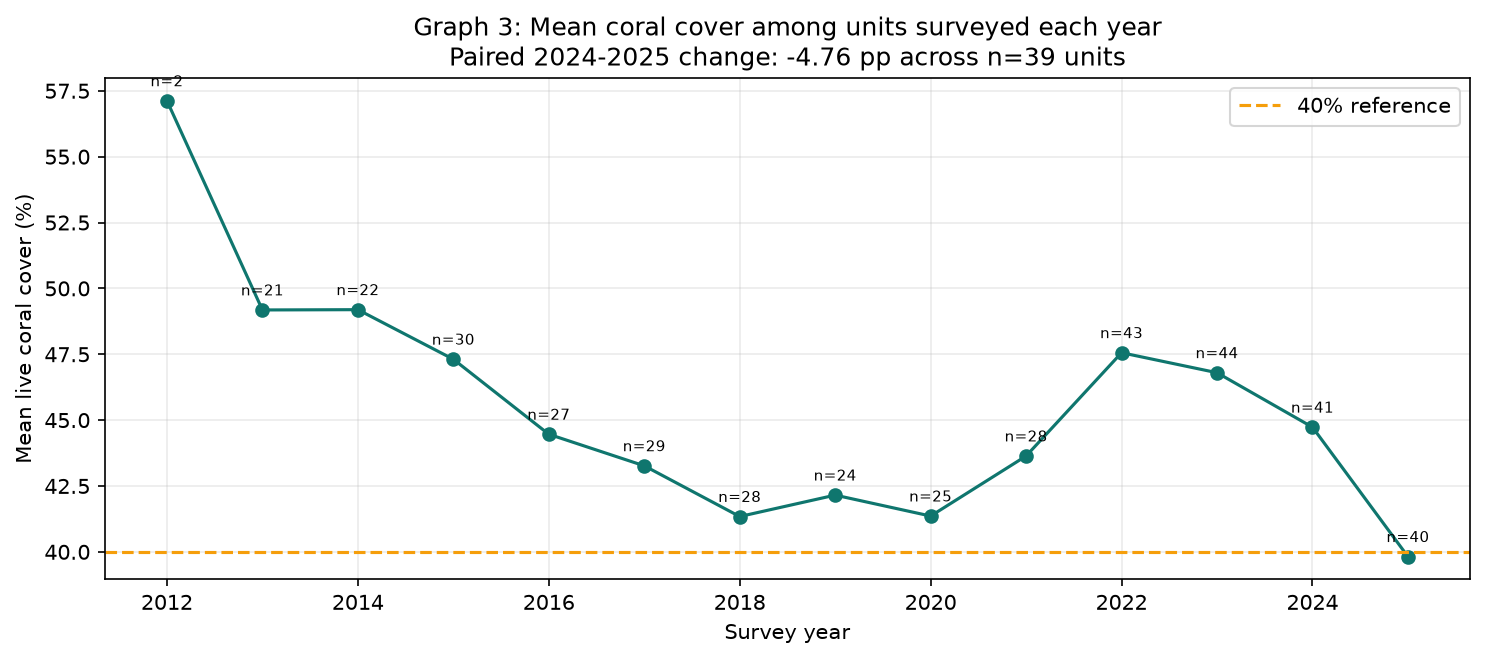

In [5]:
paired_row = paired.row(0, named=True)
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.plot(annual["survey_year"], annual["mean_lcc"], marker="o", color="#0f766e")
for row in annual.iter_rows(named=True):
    ax.annotate(f"n={row['surveyed_units']}", (row["survey_year"], row["mean_lcc"]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7)
ax.axhline(40, color="#f59e0b", linestyle="--", label="40% reference")
ax.set_title(
    "Graph 3: Mean coral cover among units surveyed each year\n"
    f"Paired 2024-2025 change: {paired_row['change_pp']:.2f} pp across n={paired_row['paired_units']} units"
)
ax.set_xlabel("Survey year")
ax.set_ylabel("Mean live coral cover (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Graph 4: Regional thermal context

NOAA Degree Heating Weeks are regional satellite context, not an island-level causal estimate.


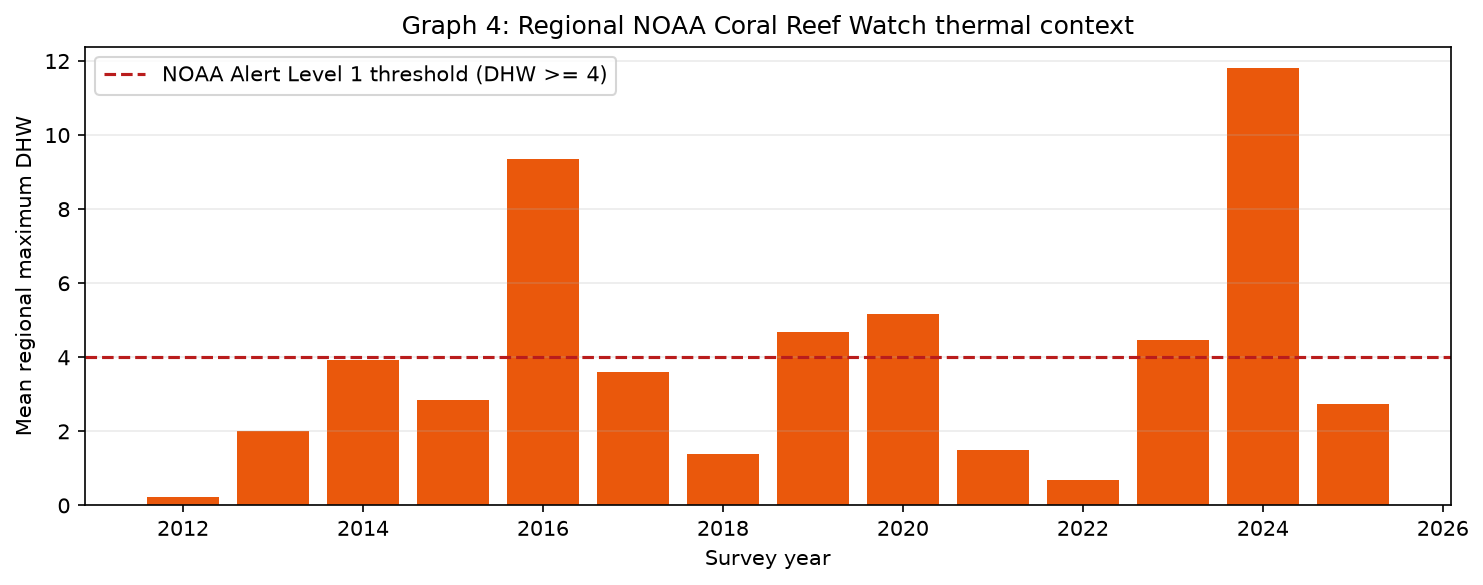

In [6]:
heat = master.group_by("survey_year").agg(pl.col("noaa_max_dhw").mean().alias("mean_dhw")).sort("survey_year")
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.bar(heat["survey_year"], heat["mean_dhw"], color="#ea580c")
ax.axhline(4, color="#b91c1c", linestyle="--", label="NOAA Alert Level 1 threshold (DHW >= 4)")
ax.set_title("Graph 4: Regional NOAA Coral Reef Watch thermal context")
ax.set_xlabel("Survey year")
ax.set_ylabel("Mean regional maximum DHW")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


---
## Phase 4: Feature Engineering

Each training row uses conditions known at one survey to predict the next observed annualised coral-cover change for that monitoring unit. Validation always trains on years earlier than the test year.


In [7]:
print(f"Training transitions: {metrics['training_transitions']}")
print(f"Forward evaluation observations: {metrics['evaluation_observations']}")
print(f"Held-forward years: {metrics['test_years']}")
display(validation_by_year)


Training transitions: 348
Forward evaluation observations: 183
Held-forward years: [2021, 2022, 2023, 2024, 2025]


target_year,n,mae,rmse,r2,bias
i64,i64,f64,f64,f64,f64
2021,24,5.699838,7.580133,0.106984,-2.403191
2022,35,6.943627,9.955006,0.116719,-0.026101
2023,43,5.755757,7.239247,0.178407,0.874699
2024,41,5.60059,7.061191,-0.286477,2.261098
2025,40,5.383332,6.73501,-0.653636,4.451967


---
## Phase 5: Factor Relationships

### Graph 5: Descriptive lagged associations

These statistics describe associations; they do not estimate causal contributions. Narrative impact absence can mean “not reported,” and the tourism contribution is not estimable from the available island-year data.


factor,analysis,n,statistic,statistic_unit,p_value,caution
str,str,i64,f64,str,f64,str
"""noaa_max_dhw""","""Spearman rank correlation""",348,-0.104578,"""rho""",0.051271,"""Descriptive lagged association…"
"""noaa_mean_ssta""","""Spearman rank correlation""",348,-0.060568,"""rho""",0.259804,"""Descriptive lagged association…"
"""grp_disturbance_indicators""","""Spearman rank correlation""",338,0.077726,"""rho""",0.153914,"""Descriptive lagged association…"
"""grp_pollution_indicators""","""Spearman rank correlation""",338,0.145976,"""rho""",0.007184,"""Descriptive lagged association…"
"""fish_parrotfish""","""Spearman rank correlation""",348,-0.032667,"""rho""",0.543603,"""Descriptive lagged association…"
"""grazer_ratio""","""Spearman rank correlation""",331,-0.059707,"""rho""",0.278749,"""Descriptive lagged association…"
"""impact_anchor""","""Mean difference: mentioned min…",348,0.753533,"""percentage points per year""",0.658005,"""Narrative mention comparison; …"
"""impact_trash""","""Mean difference: mentioned min…",348,-0.390907,"""percentage points per year""",0.604044,"""Narrative mention comparison; …"
"""impact_bleaching""","""Mean difference: mentioned min…",348,0.871002,"""percentage points per year""",0.547129,"""Narrative mention comparison; …"


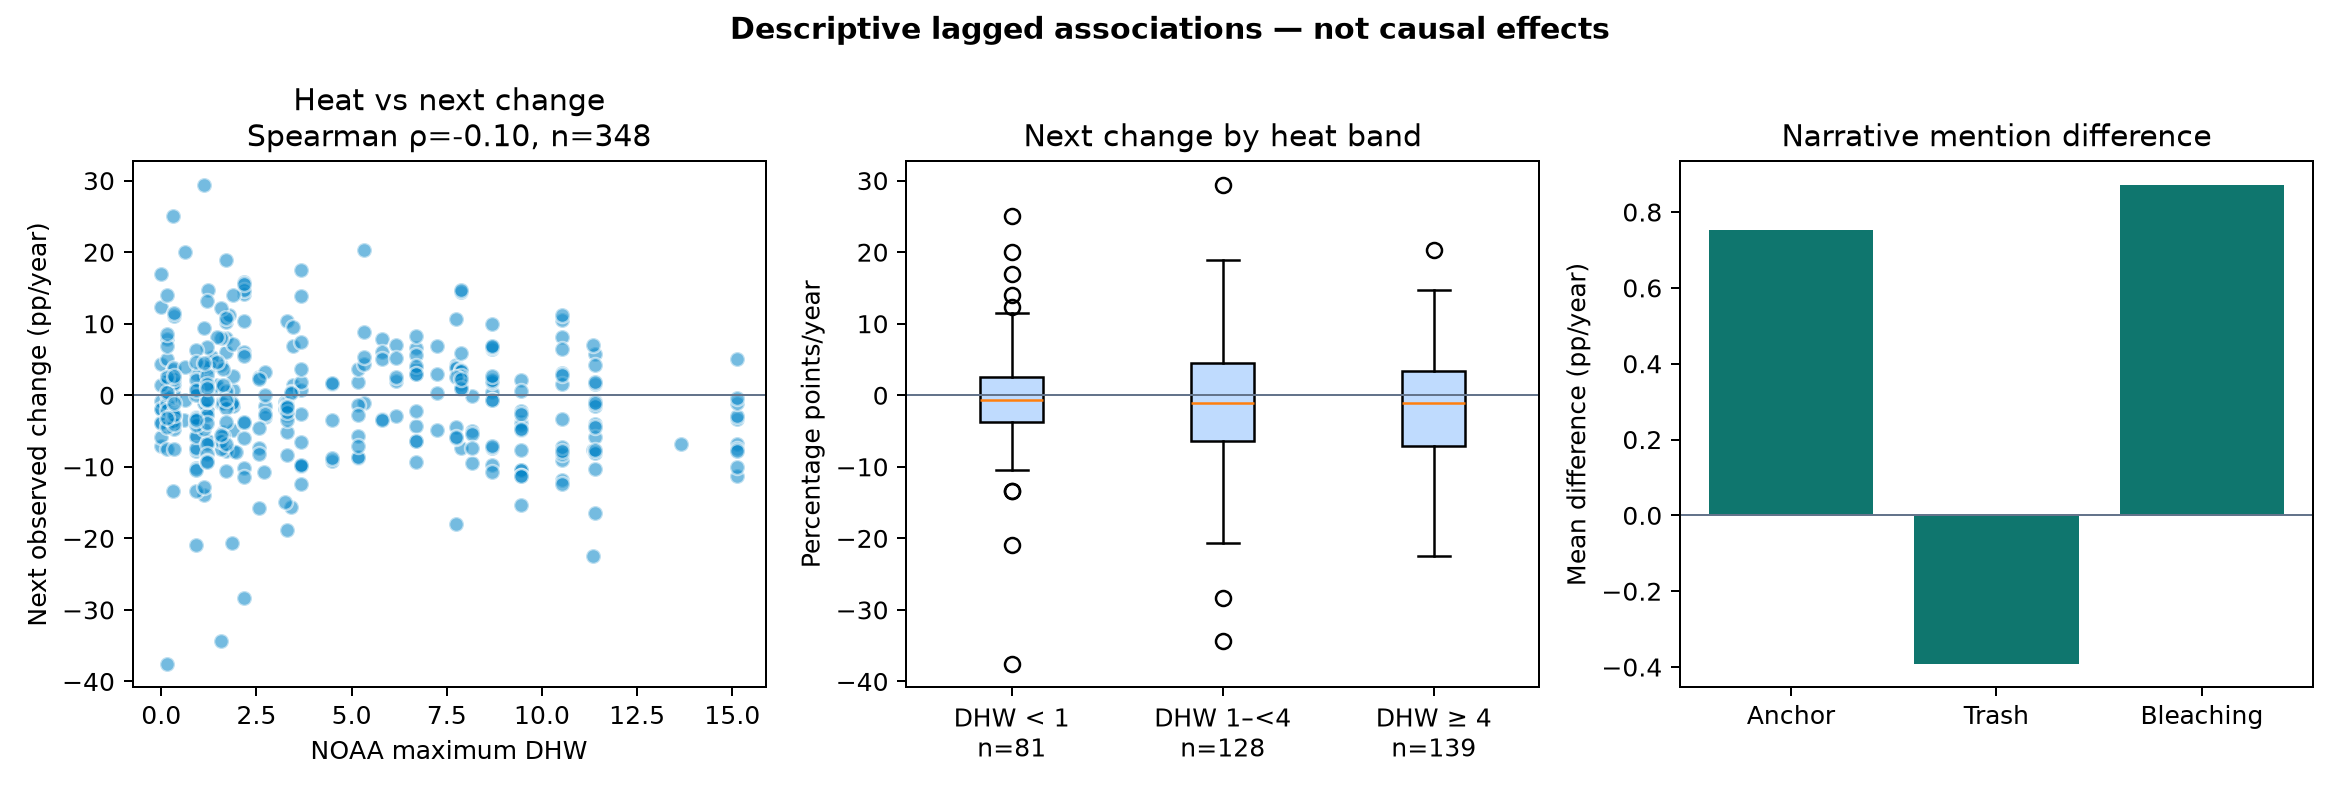

In [8]:
display(factors)
display(Image(filename=str(ROOT / "output/fig4_factor_relationships.png")))


### Graph 6: All measured factor associations

This common-scale view compares all 22 production features and two NOAA context variables against the next observed coral-cover change. Most relationships are weak or very weak. `island_vs_region_pct` is the island's live coral cover minus Reef Check's published eco-region average for that survey year, in percentage points. Its negative association is a baseline-condition signal, not a cause, and may partly reflect mean reversion. NOAA variables remain context only.


factor,group,evidence_role,n,spearman_rho,p_value,strength
str,str,str,i64,f64,f64,str
"""island_vs_region_pct""","""Coral condition and trend""","""production_feature""",346,-0.320133,1.0985e-9,"""Moderate"""
"""live_coral_cover_pct""","""Coral condition and trend""","""production_feature""",348,-0.294772,2.0932e-8,"""Weak"""
"""lcc_change_rate""","""Coral condition and trend""","""production_feature""",301,-0.217763,0.00014,"""Weak"""
"""survey_year""","""Time and geography""","""production_feature""",348,-0.13673,0.010665,"""Weak"""
"""impact_cot""","""Reported impacts""","""production_feature""",348,-0.122073,0.022752,"""Weak"""
…,…,…,…,…,…,…
"""longitude""","""Time and geography""","""production_feature""",348,0.056397,0.294119,"""Very weak"""
"""grp_disturbance_indicators""","""Substrate condition""","""production_feature""",338,0.077726,0.153914,"""Very weak"""
"""grp_sand""","""Substrate condition""","""production_feature""",338,0.128528,0.018078,"""Weak"""


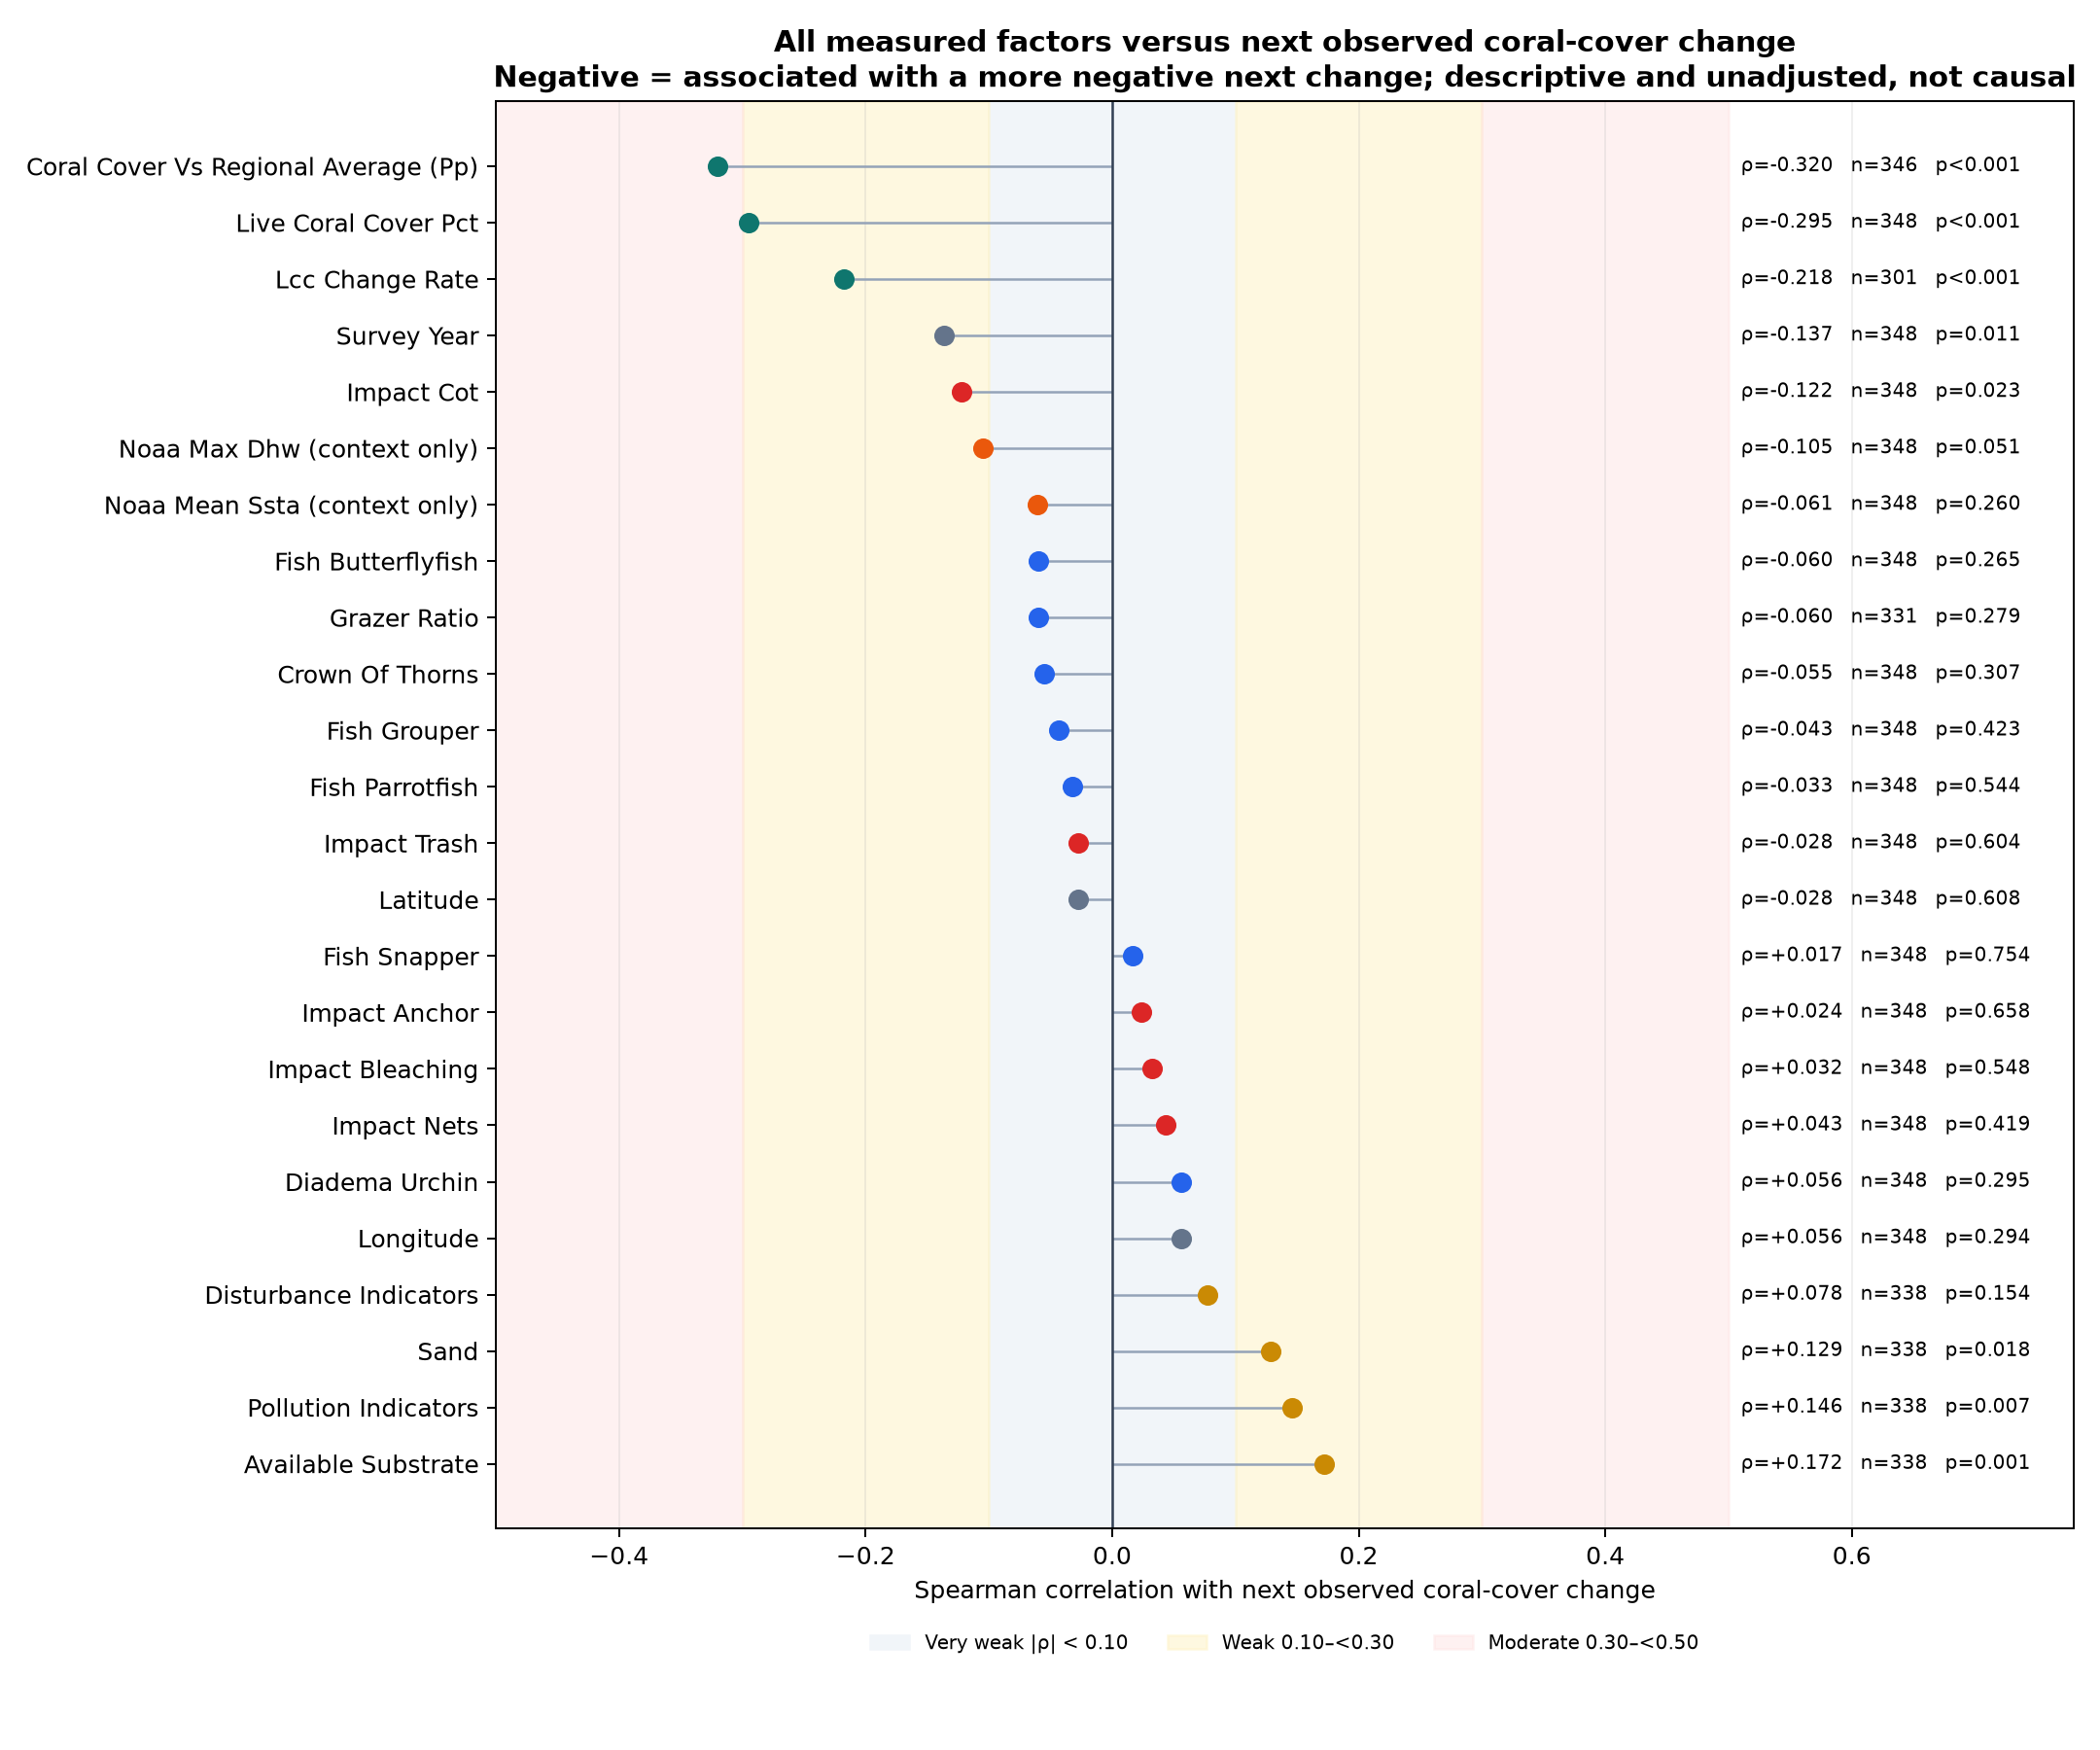

In [9]:
display(all_factors.select([
    "factor", "group", "evidence_role", "n", "spearman_rho", "p_value", "strength"
]))
display(Image(filename=str(ROOT / "output/fig5_all_factor_associations.png")))


The former controllable-versus-uncontrollable percentage chart is intentionally retired because its weights were not estimated from data.


---
## Phase 6: Economic Valuation

### Graph 7: Published historical economic context

The Department of Marine Park Malaysia reports a rounded RM8.7 billion annual Total Economic Value for six evaluated Malaysian marine-park archipelagos during 2011-2015. The values below reproduce that publication; they are not current prices and were not calculated by ReefSafe.


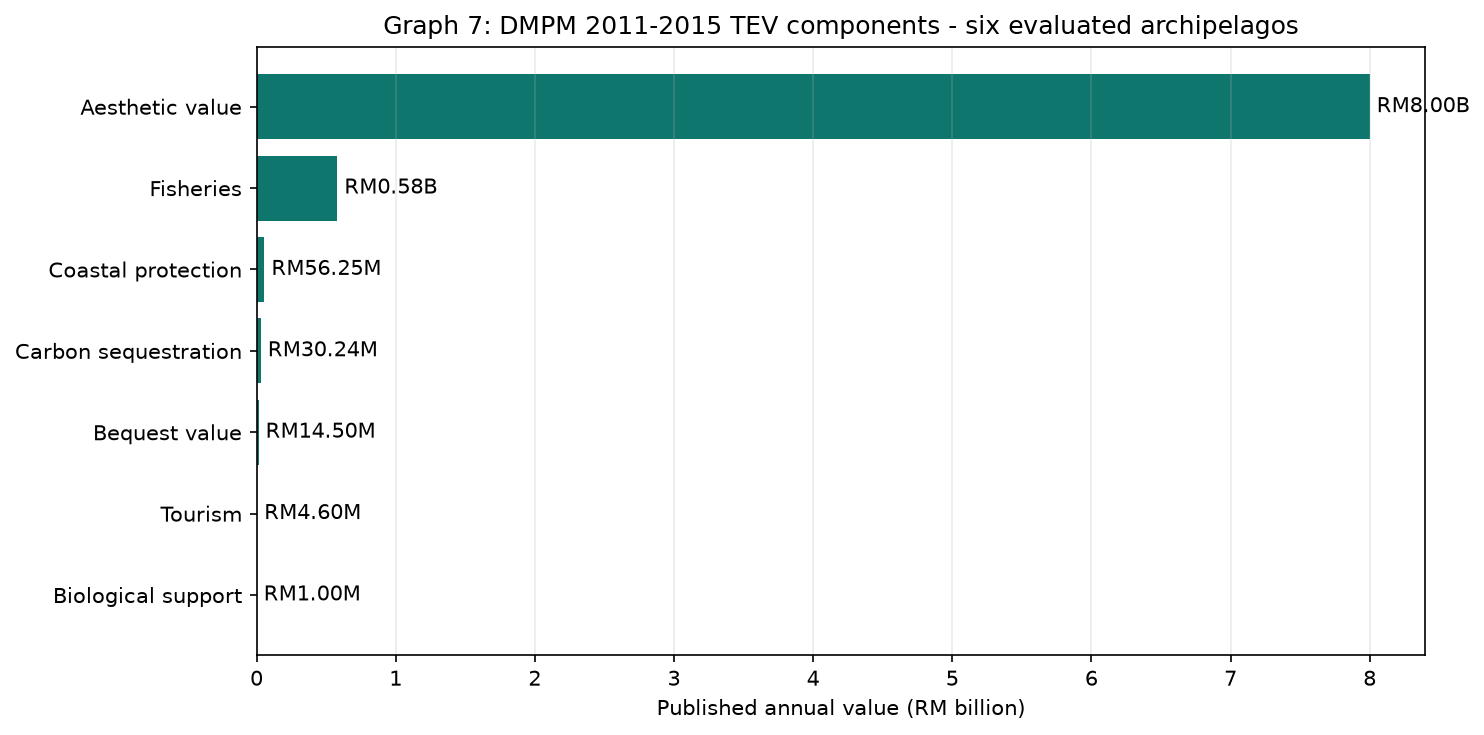

Published annual benchmark for six evaluated Malaysian marine-park archipelagos; not a current ReefSafe estimate
Published rounded headline: RM8.7 billion/year


In [10]:
components = pl.DataFrame(tev["components"]).sort("annual_value_myr")
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
values = components["annual_value_myr"].to_numpy() / 1e9
bars = ax.barh(components["component"], values, color="#0f766e")
for bar, value in zip(bars, values):
    label = f"RM{value:.2f}B" if value >= 0.1 else f"RM{value * 1000:.2f}M"
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, " " + label, va="center")
ax.set_xlabel("Published annual value (RM billion)")
ax.set_title("Graph 7: DMPM 2011-2015 TEV components - six evaluated archipelagos")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
print(tev["scope_note"])
print(f"Published rounded headline: RM{tev['reported_total_myr'] / 1e9:.1f} billion/year")


The former multi-year economic scenario is intentionally retired because ReefSafe has no defensible intervention-effect or revenue-loss estimates.


---
## Phase 7: Predictive Modeling and Priority Screening

### Graph 9: Forward model comparison

The lowest-MAE candidate is selected automatically. A small improvement over the mean baseline supports screening only, not forecasting or enforcement.


model,MAE,RMSE,R2
str,f64,f64,f64
"""Gradient boosting""",5.859443,7.738823,0.069761
"""Ridge regression""",5.989869,7.938954,0.021026
"""Baseline mean""",5.991037,8.100134,-0.019129
"""Random forest""",6.073604,8.016583,0.001787


Selected candidate: Gradient boosting
MAE improvement over baseline: 2.2%


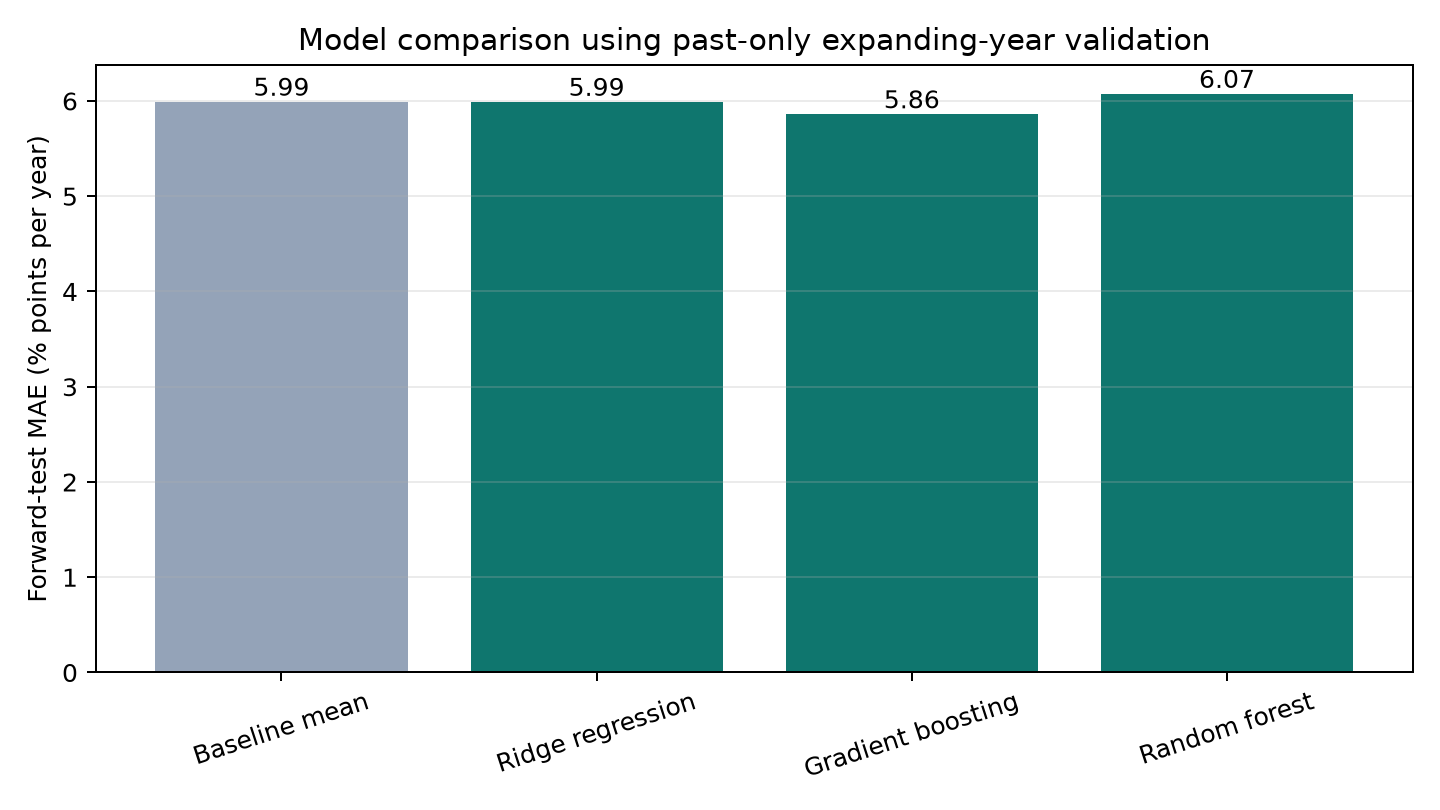

In [11]:
comparison = pl.DataFrame([
    {"model": name, **values}
    for name, values in metrics["model_comparison"].items()
]).sort("MAE")
display(comparison)
print(f"Selected candidate: {metrics['best_candidate']}")
print(f"MAE improvement over baseline: {metrics['mae_improvement_pct']:.1f}%")
display(Image(filename=str(ROOT / "output/fig1_model_performance_cv.png")))


### Graph 10: Held-forward permutation importance

Importance indicates predictive association, not causality. Negative values mean permutation did not improve held-forward error for that feature.


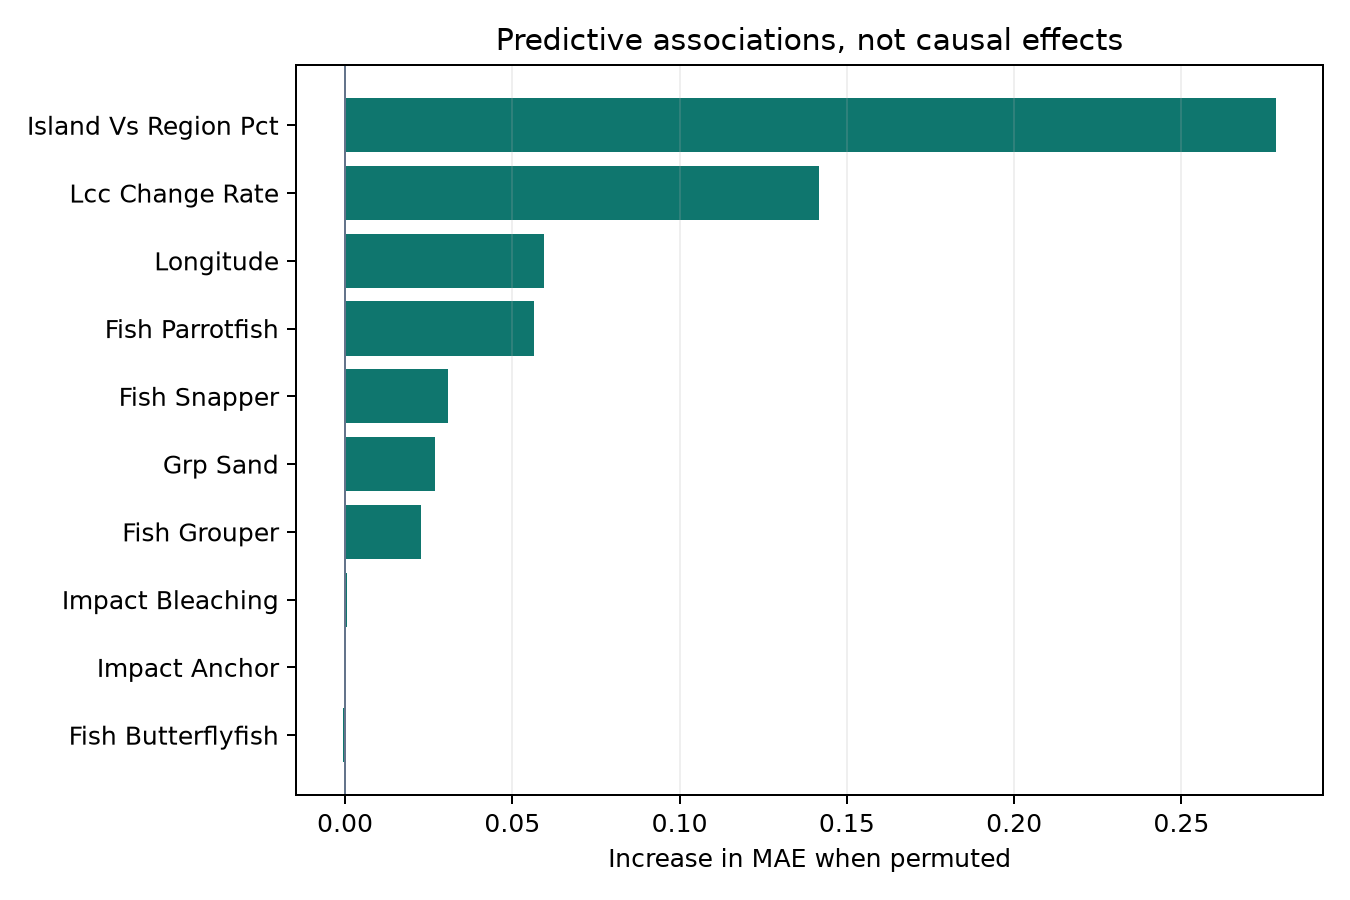

In [12]:
display(Image(filename=str(ROOT / "output/fig3_feature_importance.png")))


### Graph 11: Forward predictions versus observations


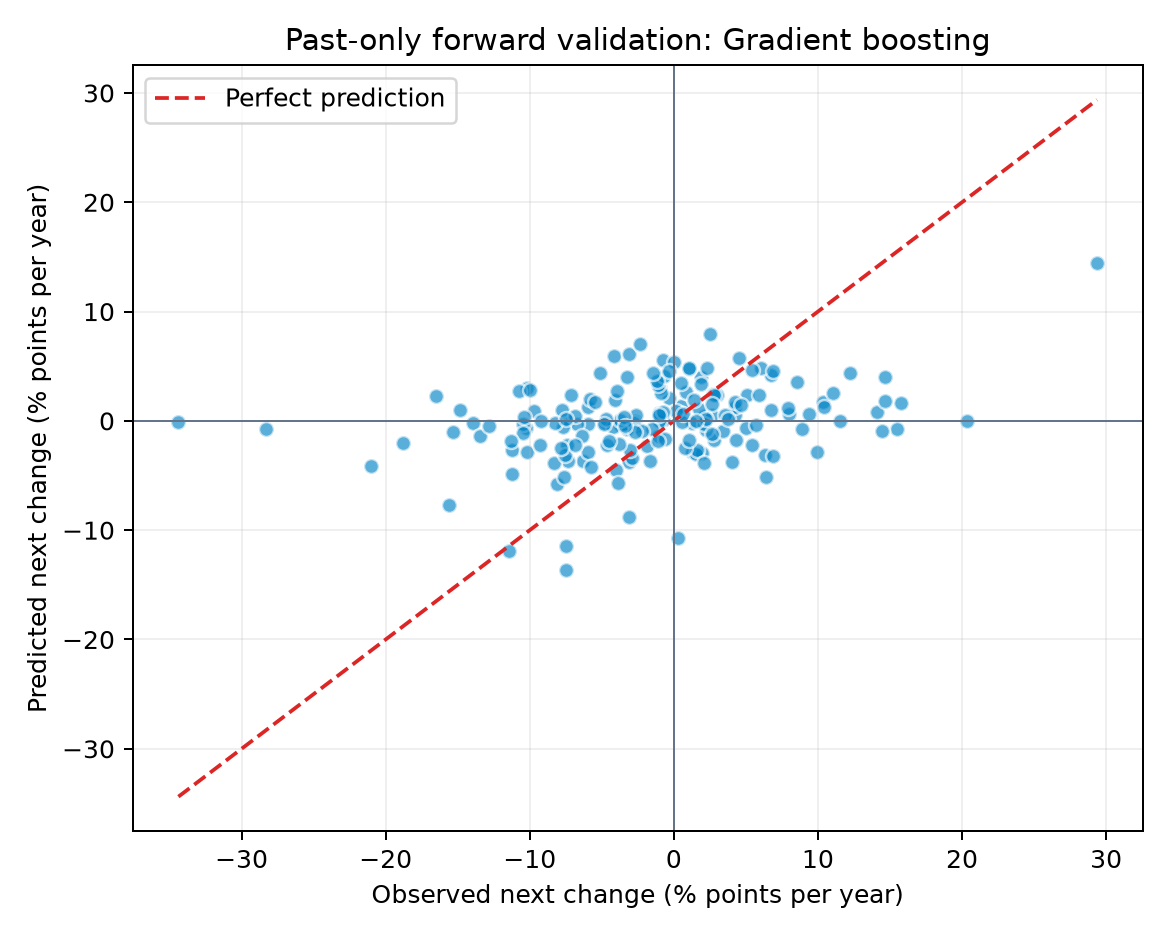

In [13]:
display(Image(filename=str(ROOT / "output/fig2_actual_vs_predicted.png")))


### Graph 12: Field-verification priority matrix

This replacement uses only model output and observed coral condition. It does not construct a human-pressure index or prescribe visitor restrictions.


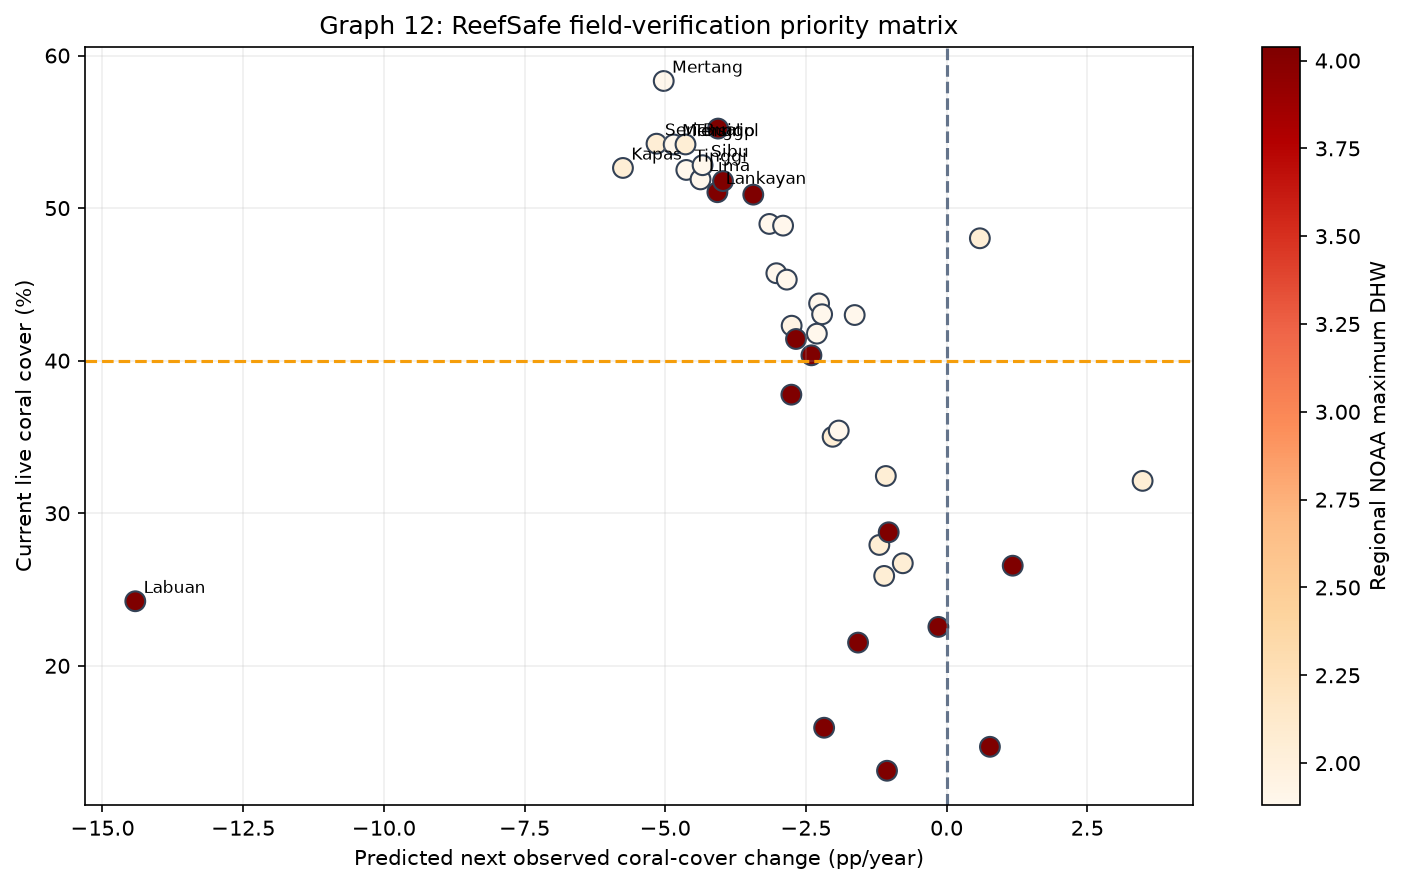

priority_rank,island,state,live_coral_cover_pct,predicted_next_change_pct_per_year,prediction_lower,prediction_upper,evidence,recommended_next_step
i64,str,str,f64,f64,f64,f64,str,str
1,"""Labuan""","""W.P. Labuan""",24.23,-14.417288,-30.671674,-0.755271,"""NOAA thermal stress observed""","""Coordinate bleaching survey; d…"
2,"""Kapas""","""Terengganu""",52.63,-5.751055,-22.00544,7.910962,"""Modelled decline; no single do…","""Prioritise field validation be…"
3,"""Seri Buat""","""Pahang""",54.22,-5.154703,-21.409088,8.507314,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
4,"""Mertang""","""Johor""",58.33,-5.026614,-21.280999,8.635403,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
5,"""Mensirip""","""Johor""",54.17,-4.849859,-21.104244,8.812158,"""Waste or pollution indicator i…","""Inspect waste and wastewater c…"
6,"""Tenggol""","""Terengganu""",54.17,-4.639589,-20.893975,9.022428,"""Waste or pollution indicator i…","""Inspect waste and wastewater c…"
7,"""Tinggi""","""Johor""",52.5,-4.625227,-20.879613,9.03679,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
8,"""Lima""","""Johor""",51.88,-4.372998,-20.627383,9.289019,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"
9,"""Sibu""","""Johor""",52.81,-4.336172,-20.590557,9.325845,"""Anchor impact mentioned in Ree…","""Inspect mooring availability a…"


In [14]:
x = priority["predicted_next_change_pct_per_year"].to_numpy()
y = priority["live_coral_cover_pct"].to_numpy()
heat_values = priority["noaa_max_dhw"].fill_null(0).to_numpy()
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
points = ax.scatter(x, y, c=heat_values, cmap="OrRd", s=90, edgecolors="#334155")
ax.axvline(0, color="#64748b", linestyle="--")
ax.axhline(40, color="#f59e0b", linestyle="--")
for row in priority.head(10).iter_rows(named=True):
    ax.annotate(row["island"], (row["predicted_next_change_pct_per_year"], row["live_coral_cover_pct"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
fig.colorbar(points, ax=ax, label="Regional NOAA maximum DHW")
ax.set_xlabel("Predicted next observed coral-cover change (pp/year)")
ax.set_ylabel("Current live coral cover (%)")
ax.set_title("Graph 12: ReefSafe field-verification priority matrix")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
display(priority.head(10).select([
    "priority_rank", "island", "state", "live_coral_cover_pct",
    "predicted_next_change_pct_per_year", "prediction_lower", "prediction_upper",
    "evidence", "recommended_next_step",
]))


---
## Project Assumptions and Governance Guardrails

1. Survey composition changes across years; annual means are descriptive unless a paired cohort is used.
2. Regional NOAA data do not prove island-level heat exposure or causality.
3. Narrative impact mentions are not a complete census of local pressure.
4. No verified island-level visitor, vessel, wastewater, or revenue series is available.
5. Prediction ranges are pooled forward-residual ranges, not formal confidence intervals.
6. Priority means “verify sooner,” not “close,” “cap,” or “penalise.”
7. The historical TEV benchmark is economic context and is not linked mathematically to ReefSafe predictions.
